<a href="https://colab.research.google.com/github/me-pranjal-jha/CNN_LAB_RGIPT/blob/main/CNN_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import random
import numpy as np
import tensorflow as tf
import sys
import matplotlib
import pandas


random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Installed package versions:")
print(f"Python      : {sys.version}")
print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Pandas      : {pandas.__version__}")

gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 0:
    print("\nGPU is available:")
    print(gpus)
else:
    print("\nNo GPU detected — running on CPU.")


Installed package versions:
Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow  : 2.19.0
NumPy       : 2.0.2
Matplotlib  : 3.10.0
Pandas      : 2.2.2

GPU is available:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


=== MNIST ===
Train images : (60000, 28, 28)
Train labels : (60000,)
Test images  : (10000, 28, 28)
Test labels  : (10000,)

=== CIFAR-10 ===
Train images : (50000, 32, 32, 3)
Train labels : (50000, 1)
Test images  : (10000, 32, 32, 3)
Test labels  : (10000, 1)

=== dtype and value range ===
MNIST   dtype = uint8, min = 0, max = 255
CIFAR-10 dtype = uint8, min = 0, max = 255

=== MNIST class distribution ===
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Minimum class count: 5421
Maximum class count: 6742
MNIST is approximately balanced.


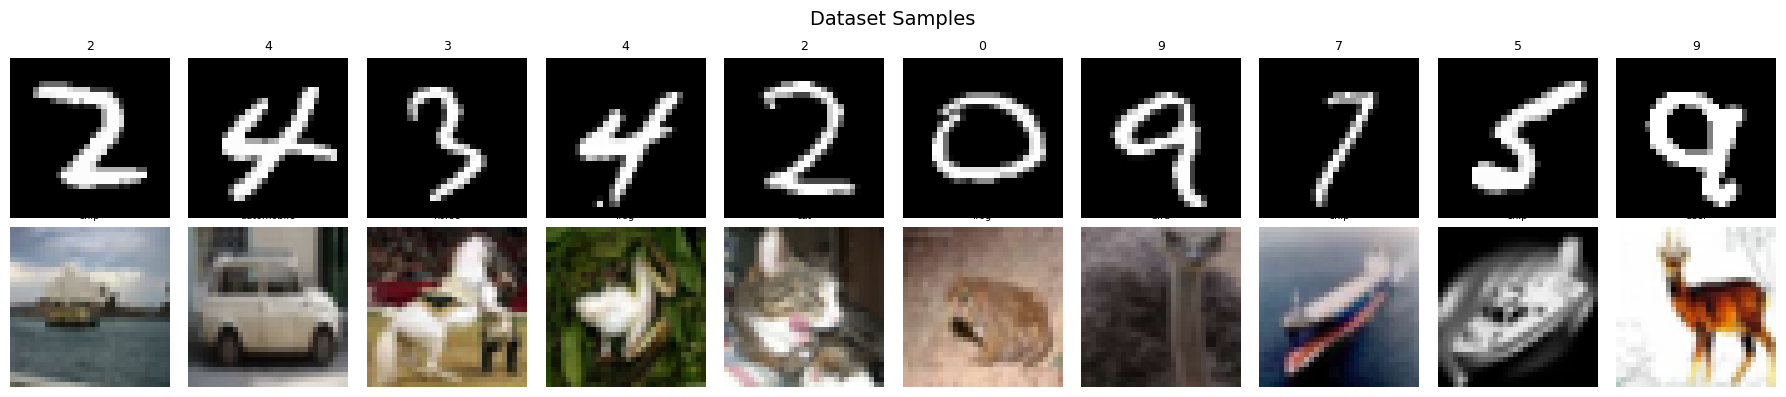

Saved dataset_samples.png


In [24]:
from tensorflow.keras.datasets import mnist, cifar10
import matplotlib.pyplot as plt
import numpy as np

(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()

print("=== MNIST ===")
print(f"Train images : {mnist_x_train.shape}")
print(f"Train labels : {mnist_y_train.shape}")
print(f"Test images  : {mnist_x_test.shape}")
print(f"Test labels  : {mnist_y_test.shape}")

print("\n=== CIFAR-10 ===")
print(f"Train images : {cifar_x_train.shape}")
print(f"Train labels : {cifar_y_train.shape}")
print(f"Test images  : {cifar_x_test.shape}")
print(f"Test labels  : {cifar_y_test.shape}")

print("\n=== dtype and value range ===")
print(f"MNIST   dtype = {mnist_x_train.dtype}, min = {mnist_x_train.min()}, max = {mnist_x_train.max()}")
print(f"CIFAR-10 dtype = {cifar_x_train.dtype}, min = {cifar_x_train.min()}, max = {cifar_x_train.max()}")

print("\n=== MNIST class distribution ===")
unique, counts = np.unique(mnist_y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Digit {cls}: {cnt} samples")

print(f"\nMinimum class count: {counts.min()}")
print(f"Maximum class count: {counts.max()}")
print("MNIST is approximately balanced.")

cifar_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

rng = np.random.default_rng(42)
mnist_idx = rng.choice(len(mnist_x_train), 10, replace=False)
cifar_idx = rng.choice(len(cifar_x_train), 10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Dataset Samples", fontsize=14)

for col, i in enumerate(mnist_idx):
    axes[0, col].imshow(mnist_x_train[i], cmap='gray')
    axes[0, col].set_title(str(mnist_y_train[i]), fontsize=9)
    axes[0, col].axis('off')

for col, i in enumerate(cifar_idx):
    axes[1, col].imshow(cifar_x_train[i])
    axes[1, col].set_title(cifar_names[cifar_y_train[i][0]], fontsize=7)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel("MNIST", fontsize=11)
axes[1, 0].set_ylabel("CIFAR-10", fontsize=11)

plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=120)
plt.show()

print("Saved dataset_samples.png")

In [25]:
def preprocess(images, labels, dataset_name='mnist'):
    print(f"\n--- {dataset_name} ---")
    print(f"Before normalise : shape={images.shape}, dtype={images.dtype}, "
          f"range=[{images.min()}, {images.max()}]")

    images = images.astype(np.float32) / 255.0
    print(f"After  normalise : shape={images.shape}, dtype={images.dtype}, "
          f"range=[{images.min():.2f}, {images.max():.2f}]")

    if dataset_name == 'mnist':
        images = images[..., np.newaxis]
        print(f"After  reshape   : shape={images.shape}")

    labels = labels.flatten()
    one_hot = np.zeros((len(labels), 10), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    print(f"After  one-hot   : shape={one_hot.shape}, sample={one_hot[0]}")

    return images, one_hot


mnist_x_train_p, mnist_y_train_p = preprocess(mnist_x_train, mnist_y_train, 'mnist')
mnist_x_test_p,  mnist_y_test_p  = preprocess(mnist_x_test,  mnist_y_test,  'mnist')

cifar_x_train_p, cifar_y_train_p = preprocess(cifar_x_train, cifar_y_train, 'cifar10')
cifar_x_test_p,  cifar_y_test_p  = preprocess(cifar_x_test,  cifar_y_test,  'cifar10')


--- mnist ---
Before normalise : shape=(60000, 28, 28), dtype=uint8, range=[0, 255]
After  normalise : shape=(60000, 28, 28), dtype=float32, range=[0.00, 1.00]
After  reshape   : shape=(60000, 28, 28, 1)
After  one-hot   : shape=(60000, 10), sample=[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

--- mnist ---
Before normalise : shape=(10000, 28, 28), dtype=uint8, range=[0, 255]
After  normalise : shape=(10000, 28, 28), dtype=float32, range=[0.00, 1.00]
After  reshape   : shape=(10000, 28, 28, 1)
After  one-hot   : shape=(10000, 10), sample=[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

--- cifar10 ---
Before normalise : shape=(50000, 32, 32, 3), dtype=uint8, range=[0, 255]
After  normalise : shape=(50000, 32, 32, 3), dtype=float32, range=[0.00, 1.00]
After  one-hot   : shape=(50000, 10), sample=[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

--- cifar10 ---
Before normalise : shape=(10000, 32, 32, 3), dtype=uint8, range=[0, 255]
After  normalise : shape=(10000, 32, 32, 3), dtype=float32, range=[0.00, 1.00]
After  one-hot   : sh

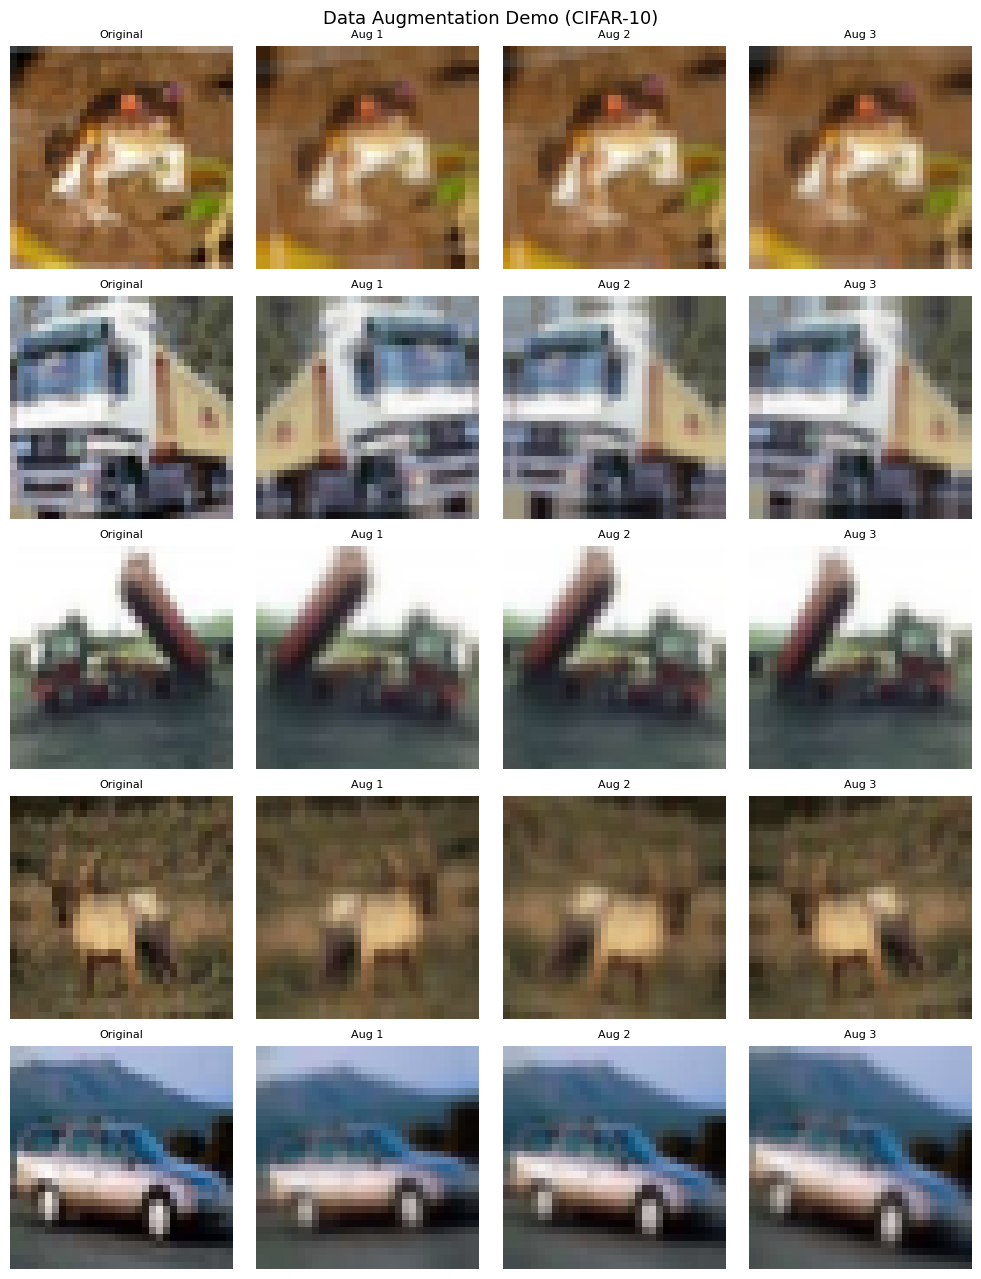

Saved augmentation_demo.png


In [26]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(10/360),
    layers.RandomZoom(0.1),
], name='augmentation')

sample_imgs = cifar_x_train_p[:5]

fig, axes = plt.subplots(5, 4, figsize=(10, 13))
fig.suptitle('Data Augmentation Demo (CIFAR-10)', fontsize=13)

for row in range(5):
    img = sample_imgs[row:row+1]
    axes[row, 0].imshow(sample_imgs[row])
    axes[row, 0].set_title('Original', fontsize=8)
    axes[row, 0].axis('off')
    for col in range(1, 4):
        aug = data_augmentation(img, training=True)[0].numpy()
        aug = np.clip(aug, 0, 1)
        axes[row, col].imshow(aug)
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png', dpi=120)
plt.show()

print('Saved augmentation_demo.png')

### Justification — Augmentation on Training Set Only

Data augmentation is applied only to the training set because its purpose is to artificially increase the diversity of the training data and help the model generalise better. By introducing variations such as flips, rotations, and zoom, the model learns to be invariant to these changes.

If augmentation is applied to the validation or test set, it would alter the original data distribution. This makes evaluation unreliable because the model is no longer being tested on real, unmodified data. Additionally, augmented data introduces randomness, which makes the evaluation non-deterministic and not reproducible. Therefore, augmentation must be restricted to the training set only.

---

### Q1. Channel Dimension in (N, H, W, C)

In a tensor of shape (N, H, W, C), the channel dimension C represents the number of features or colour channels present at each pixel location.

For a grayscale image, C = 1, meaning each pixel contains only one intensity value representing brightness. For an RGB image, C = 3, where each pixel contains three values corresponding to red, green, and blue colour intensities.

In convolutional neural networks, filters operate across all channels simultaneously. Each filter has separate weights for each channel, and the outputs are combined to produce a single feature map. This allows the network to capture both spatial and colour-based patterns.

---

### Q2. Handling Large Images (1024×1024)

When working with very large images like 1024×1024, loading the entire dataset into memory can cause out-of-memory (OOM) errors. Two effective strategies to handle this are:

1. **Using tf.data with batching and prefetching**  
   Instead of loading all data at once, images are loaded in small batches during training. The `tf.data.Dataset` pipeline allows efficient streaming of data from disk, and prefetching overlaps data loading with computation, improving performance and reducing memory usage.

2. **Patch-based training**  
   Large images can be divided into smaller patches (for example, 256×256), and the model is trained on these patches instead of the full image. This significantly reduces memory requirements while still allowing the model to learn local features. Over time, the model sees different parts of the image and learns the overall distribution.

---

### Q3. Problem with Normalising Using Test Set Statistics

Normalising the test set using its own mean and standard deviation leads to data leakage. This means that information from the test data is being used during preprocessing, which should not happen because the test set is meant to represent completely unseen data.

As a result, the model evaluation becomes biased and overly optimistic, since it indirectly benefits from knowledge of the test data distribution. It also reduces reproducibility, as the statistics would change if the test set changes.

The correct approach is to compute normalisation parameters (mean and standard deviation) using only the training set, and then apply those same values to both the validation and test sets.

In [27]:
def conv2d(image, kernel, stride=1, padding=0):
    """2D convolution using only NumPy — no external conv utilities."""
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    ih, iw = image.shape
    kh, kw = kernel.shape

    out_h = (ih - kh) // stride + 1
    out_w = (iw - kw) // stride + 1
    output = np.zeros((out_h, out_w), dtype=np.float64)

    for r in range(out_h):
        for c in range(out_w):
            patch = image[r*stride : r*stride+kh, c*stride : c*stride+kw]
            output[r, c] = np.sum(patch * kernel)

    return output

# ─── Test ─────────────────────────────────────────────────────────────────────
test_image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
], dtype=np.float64)

sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)

result = conv2d(test_image, sobel_x, stride=1, padding=0)

print("Feature map output:")
print(result)

# Manual shape verification: floor((5-3+2*0)/1)+1 = 3
expected_shape = ((5 - 3 + 2*0) // 1 + 1, (5 - 3 + 2*0) // 1 + 1)
print(f"\nOutput shape : {result.shape}  (expected {expected_shape})")

Feature map output:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape : (3, 3)  (expected (3, 3))


## Problem 2 — Output Size Derivation

Formula: `Output = floor((Input - Kernel + 2×Padding) / Stride) + 1`

**(a)** Input=28, K=5, P=0, S=1  
`floor((28 - 5 + 0) / 1) + 1 = 23 + 1 = **24×24**`

**(b)** Input=28, K=3, P=1, S=1  
`floor((28 - 3 + 2) / 1) + 1 = 27 + 1 = **28×28**`  *("same" padding preserves spatial size)*

**(c)** Input=32, K=3, P=0, S=2  
`floor((32 - 3 + 0) / 2) + 1 = floor(29/2) + 1 = 14 + 1 = **15×15**`

**(d)** Two consecutive layers on 32×32:  
Layer 1: K=3, P=1, S=1 → `floor((32-3+2)/1)+1 = 32` → **32×32**  
Layer 2: K=3, P=0, S=1 → `floor((32-3+0)/1)+1 = 30` → **30×30**

In [28]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, AveragePooling2D, Flatten, Dense, Activation
)

def build_lenet5():
    model = Sequential([
        # Block 1
        Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)),
        Activation('tanh'),
        AveragePooling2D(pool_size=(2,2), strides=2),
        # Block 2
        Conv2D(16, (5,5), padding='valid'),
        Activation('tanh'),
        AveragePooling2D(pool_size=(2,2), strides=2),
        # Classifier
        Flatten(),
        Dense(120), Activation('tanh'),
        Dense(84),  Activation('tanh'),
        Dense(10,   activation='softmax'),
    ], name='LeNet-5')
    return model

lenet = build_lenet5()
lenet.summary()

# ─── Manual param count for first Conv2D ──────────────────────────────────────
# Formula: (K_H × K_W × C_in + 1) × C_out
# = (5 × 5 × 1 + 1) × 6 = 26 × 6 = 156
manual = (5*5*1 + 1) * 6
print(f"\nManual param count (Conv2D-1): ({5}×{5}×{1}+1)×{6} = {manual}")

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


Manual param count (Conv2D-1): (5×5×1+1)×6 = 156


**Why AvgPool in LeNet-5 vs MaxPool today?**  
LeCun's 1998 paper used average pooling because it was theoretically motivated by
sub-sampling and computing local averages kept gradient flow smooth. MaxPooling is
preferred today because it retains the strongest (most activated) feature in each
window, providing better translation invariance and sharper feature detection.
Empirically MaxPooling leads to faster convergence and higher accuracy on modern
benchmarks.

## Problem 4 — Custom CNN for CIFAR-10

**Architecture sketch:**
```
Input (32×32×3)
  │
  ├─ Block 1: Conv2D(32, 3×3) → BN → ReLU → MaxPool(2×2)  → 16×16×32
  ├─ Block 2: Conv2D(64, 3×3) → BN → ReLU → MaxPool(2×2)  →  8×8×64
  ├─ Block 3: Conv2D(128,3×3) → BN → ReLU → MaxPool(2×2)  →  4×4×128
  │
  ├─ GlobalAveragePooling2D                                →  128
  ├─ Dense(256) → ReLU → Dropout(0.4)
  └─ Dense(10)  → Softmax
```

**Design rationale (3–4 sentences):**  
Three convolutional blocks with doubling filter counts (32→64→128) allow the network
to learn progressively more abstract representations. Batch Normalisation after each
Conv2D stabilises training and reduces internal covariate shift, allowing a higher
learning rate. GlobalAveragePooling collapses the spatial map to a single vector per
filter, drastically reducing parameters vs Flatten and acting as a spatial regulariser.
Dropout(0.4) in the dense head prevents co-adaptation of neurons and reduces
overfitting on the relatively small CIFAR-10 training set.

In [29]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras import Model

def build_custom_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Block 2
    x = Conv2D(64, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Block 3
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='Custom_CIFAR_CNN')

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "Custom_CIFAR_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

## Analysis Q1–Q3 (Task 2)

**Q1. Two 3×3 vs one 5×5 (same number of filters F):**  
Params for two 3×3 layers: `2 × (3×3×F + 1)×F ≈ 18F²`  
Params for one 5×5 layer: `(5×5×F + 1)×F ≈ 25F²`  
Two 3×3 layers use ~28% fewer parameters. They also provide two non-linearities
instead of one, richer feature extraction, and the same 5×5 effective receptive
field.

**Q2. Batch Normalisation:**  
BatchNorm normalises each mini-batch's activations to zero mean and unit variance,
then applies learnable scale γ and shift β. It is typically placed after Conv2D and
before the activation (though post-activation also works). Empirical benefits:
(1) allows higher learning rates without divergence; (2) acts as a mild regulariser,
often reducing the need for Dropout; (3) smooths the loss landscape, leading to
faster convergence.

**Q3. GlobalAveragePooling vs Flatten:**  
GAP computes the spatial mean of each feature map, collapsing (H, W, C) → (C,).
This removes all spatial information. Replacing GAP with Flatten would turn each
4×4×128 tensor into a 2048-dim vector, adding `(2048+1)×256 ≈ 524,544` extra
parameters to the first Dense layer alone, massively increasing overfitting risk
and memory cost.

In [30]:
from tensorflow.keras.optimizers import SGD

tf.random.set_seed(42)
lenet = build_lenet5()
lenet.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = lenet.fit(
    mnist_x_train_p, mnist_y_train_p,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss, test_acc = lenet.evaluate(mnist_x_test_p, mnist_y_test_p, verbose=0)
print(f"\nFinal test accuracy: {test_acc:.4f}")

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7811 - loss: 0.8792 - val_accuracy: 0.9080 - val_loss: 0.3683
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8960 - loss: 0.3766 - val_accuracy: 0.9267 - val_loss: 0.2717
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9128 - loss: 0.3041 - val_accuracy: 0.9362 - val_loss: 0.2281
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9248 - loss: 0.2609 - val_accuracy: 0.9442 - val_loss: 0.1983
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9335 - loss: 0.2286 - val_accuracy: 0.9513 - val_loss: 0.1751
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9404 - loss: 0.2026 - val_accuracy: 0.9583 - val_loss: 0.1565
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9470 - loss: 0.1812 - val_accuracy: 0.9618 - val_loss: 0.1413
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9519 - loss: 0.1636 - val_accuracy: 0.

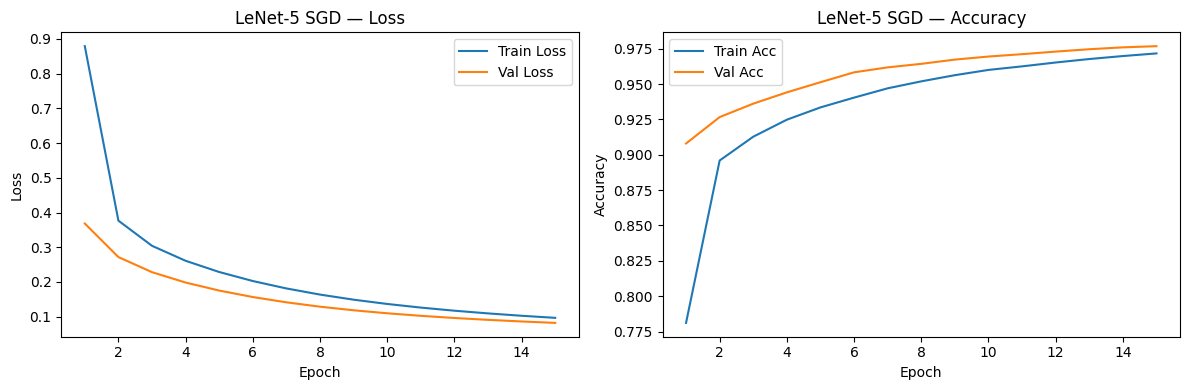

Saved lenet_sgd_curves.png


In [31]:
def plot_history(history, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history.history['loss']) + 1)

    ax1.plot(epochs, history.history['loss'],     label='Train Loss')
    ax1.plot(epochs, history.history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend()

    ax2.plot(epochs, history.history['accuracy'],     label='Train Acc')
    ax2.plot(epochs, history.history['val_accuracy'], label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=120)
    plt.show()

plot_history(history_sgd, 'LeNet-5 SGD', 'lenet_sgd_curves.png')
print('Saved lenet_sgd_curves.png')

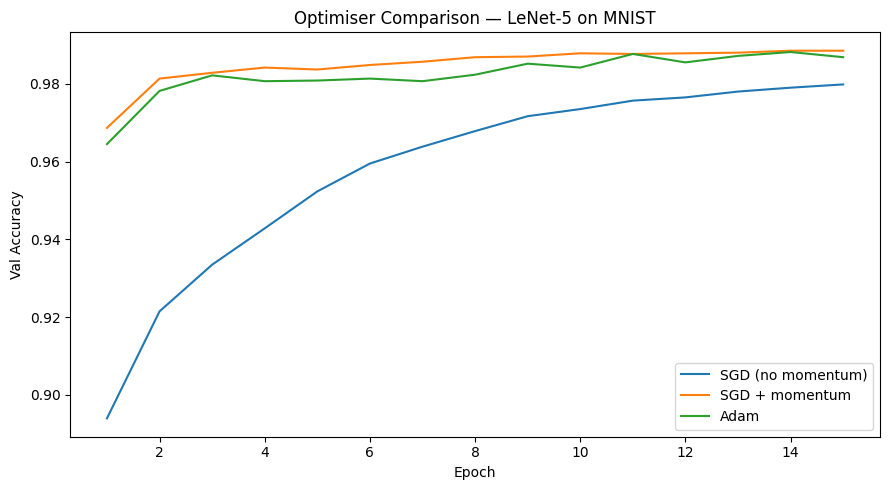

Saved optimiser_comparison.png


In [32]:
from tensorflow.keras.optimizers import Adam

optimisers = [
    ('SGD (no momentum)',   SGD(learning_rate=0.01)),
    ('SGD + momentum',      SGD(learning_rate=0.01, momentum=0.9)),
    ('Adam',                Adam(learning_rate=0.001)),
]

fig, ax = plt.subplots(figsize=(9, 5))

for name, opt in optimisers:
    tf.random.set_seed(42)
    m = build_lenet5()
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(mnist_x_train_p, mnist_y_train_p,
              epochs=15, batch_size=64,
              validation_split=0.1, verbose=0)
    ax.plot(range(1, 16), h.history['val_accuracy'], label=name)

ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_title('Optimiser Comparison — LeNet-5 on MNIST')
ax.legend()
plt.tight_layout()
plt.savefig('optimiser_comparison.png', dpi=120)
plt.show()
print('Saved optimiser_comparison.png')

In [33]:
import pandas as pd

LRS    = [0.1, 0.01, 0.001]
BSIZES = [32, 128]
results = {}

for lr in LRS:
    row = {}
    for bs in BSIZES:
        tf.random.set_seed(42)
        m = build_custom_cnn()
        m.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
        h = m.fit(cifar_x_train_p, cifar_y_train_p,
                  epochs=10, batch_size=bs,
                  validation_split=0.1, verbose=0)
        val_acc = max(h.history['val_accuracy'])
        row[bs] = round(val_acc, 4)
        print(f"LR={lr}, BS={bs} → val_acc={val_acc:.4f}")
    results[lr] = row

df = pd.DataFrame(results, index=BSIZES).T
df.index.name = 'LR \ BS'
print("\nGrid search results:")
print(df)

<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:23: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1866/1364592930.py:23: SyntaxWarning: invalid escape sequence '\ '
  df.index.name = 'LR \ BS'


LR=0.1, BS=32 → val_acc=0.0970
LR=0.1, BS=128 → val_acc=0.2022
LR=0.01, BS=32 → val_acc=0.6278
LR=0.01, BS=128 → val_acc=0.7168
LR=0.001, BS=32 → val_acc=0.6894
LR=0.001, BS=128 → val_acc=0.6594

Grid search results:
            32      128
LR \ BS                
0.100    0.0970  0.2022
0.010    0.6278  0.7168
0.001    0.6894  0.6594


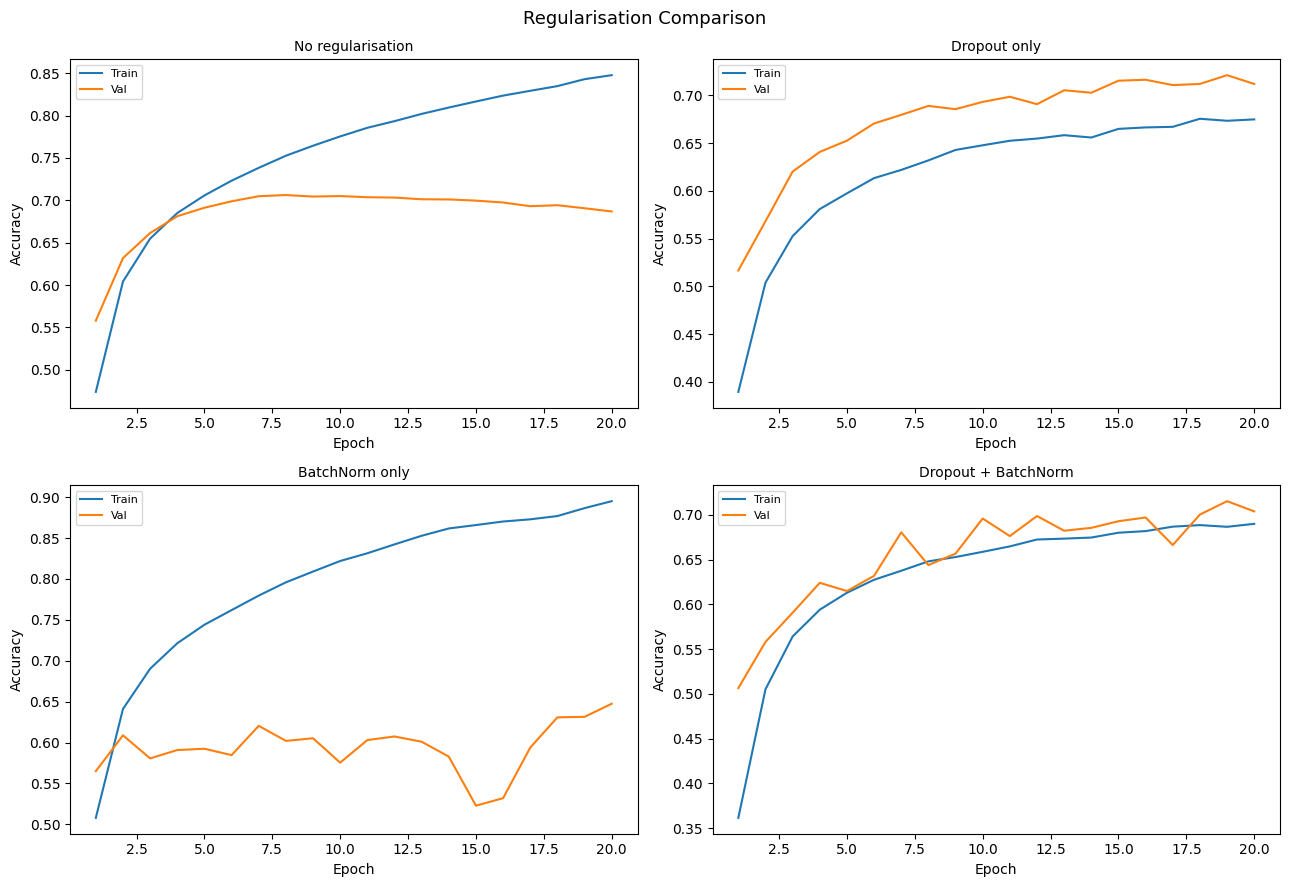

            Variant  Train-Val Gap
  No regularisation         0.1608
       Dropout only        -0.0371
     BatchNorm only         0.2477
Dropout + BatchNorm        -0.0139


In [34]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, Flatten, Dense, Dropout
)
from tensorflow.keras import Model

def build_reg_cnn(use_dropout=False, use_bn=False):
    inputs = Input(shape=(32,32,3))

    for filters in [32, 64]:
        x = Conv2D(filters, (3,3), padding='same', activation=None if use_bn else 'relu')(
            inputs if filters == 32 else x)
        if use_bn:
            x = BatchNormalization()(x)
            x = Activation('relu')(x)
        x = MaxPooling2D(2)(x)
        if use_dropout:
            x = Dropout(0.3)(x)

    x = Flatten()(x)
    if use_dropout:
        x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)
    return Model(inputs, outputs)

variants = [
    ('No regularisation',       build_reg_cnn(False, False)),
    ('Dropout only',            build_reg_cnn(True,  False)),
    ('BatchNorm only',          build_reg_cnn(False, True)),
    ('Dropout + BatchNorm',     build_reg_cnn(True,  True)),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
gaps = []

for idx, (name, model) in enumerate(variants):
    tf.random.set_seed(42)
    model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    h = model.fit(cifar_x_train_p, cifar_y_train_p,
                  epochs=20, batch_size=64,
                  validation_split=0.1, verbose=0)
    ax = axes[idx//2][idx%2]
    ep = range(1, 21)
    ax.plot(ep, h.history['accuracy'],     label='Train')
    ax.plot(ep, h.history['val_accuracy'], label='Val')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    gap = h.history['accuracy'][-1] - h.history['val_accuracy'][-1]
    gaps.append({'Variant': name, 'Train-Val Gap': round(gap, 4)})

plt.suptitle('Regularisation Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('regularisation_curves.png', dpi=120)
plt.show()

print(pd.DataFrame(gaps).to_string(index=False))


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 23: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


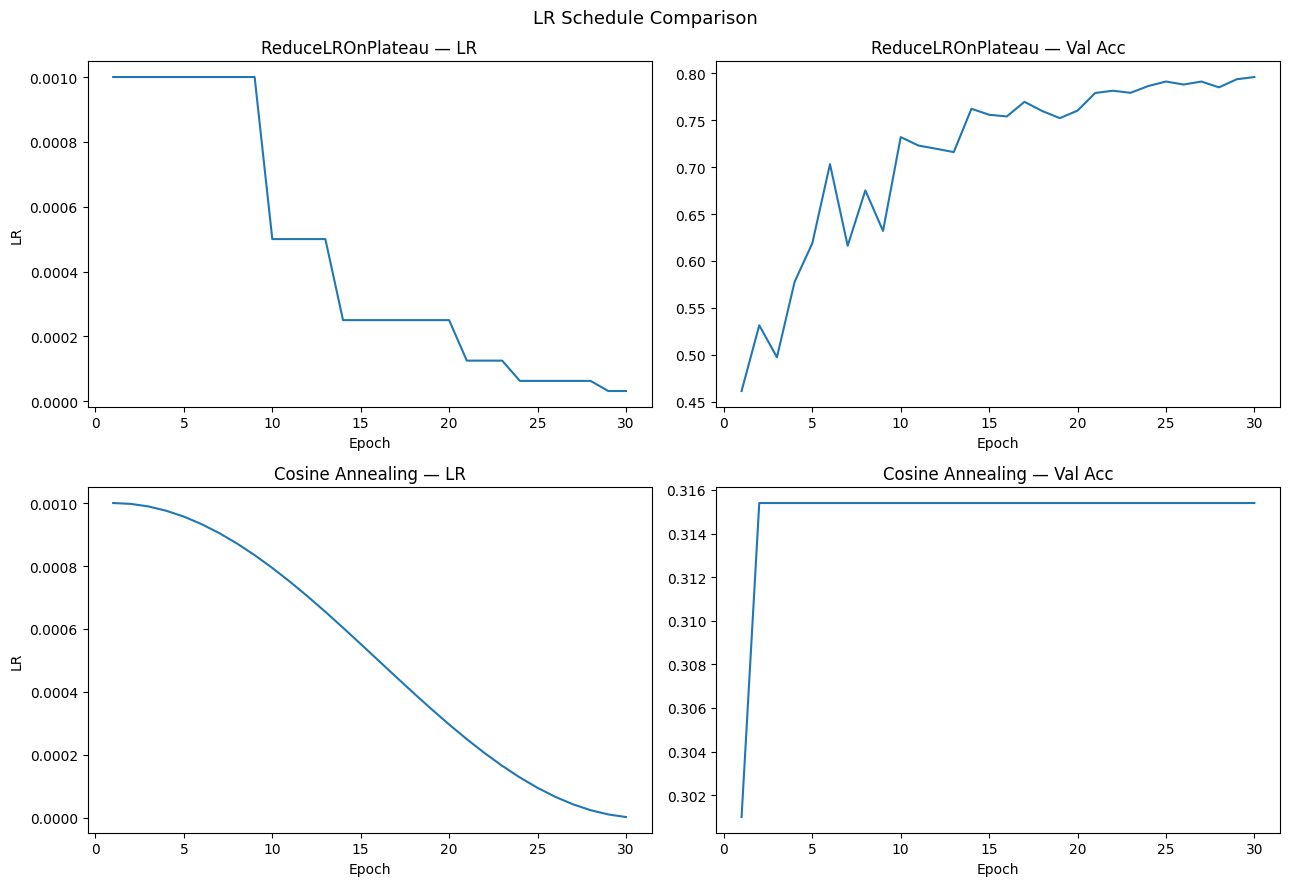

Saved lr_schedule_comparison.png


In [35]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ─── Helper: record LR each epoch ─────────────────────────────────────────────
class LRLogger(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.model.history.history.setdefault('lr', []).append(
            float(self.model.optimizer.learning_rate))

# ─── (a) ReduceLROnPlateau ────────────────────────────────────────────────────
tf.random.set_seed(42)
m1 = build_custom_cnn()
m1.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
rlrop = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
h1 = m1.fit(cifar_x_train_p, cifar_y_train_p,
            epochs=30, batch_size=64, validation_split=0.1,
            callbacks=[rlrop, LRLogger()], verbose=0)

# ─── (b) Cosine Annealing ─────────────────────────────────────────────────────
cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, decay_steps=30)

tf.random.set_seed(42)
m2 = build_custom_cnn()
m2.compile(optimizer=Adam(cosine_decay), loss='categorical_crossentropy', metrics=['accuracy'])
h2 = m2.fit(cifar_x_train_p, cifar_y_train_p,
            epochs=30, batch_size=64, validation_split=0.1, verbose=0)

# ─── Plot ─────────────────────────────────────────────────────────────────────
ep = range(1, 31)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(ep, h1.history.get('lr', [1e-3]*30))
axes[0,0].set_title('ReduceLROnPlateau — LR'); axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('LR')

axes[0,1].plot(ep, h1.history['val_accuracy'])
axes[0,1].set_title('ReduceLROnPlateau — Val Acc'); axes[0,1].set_xlabel('Epoch')

cosine_lrs = [cosine_decay(i).numpy() for i in range(30)]
axes[1,0].plot(ep, cosine_lrs)
axes[1,0].set_title('Cosine Annealing — LR'); axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('LR')

axes[1,1].plot(ep, h2.history['val_accuracy'])
axes[1,1].set_title('Cosine Annealing — Val Acc'); axes[1,1].set_xlabel('Epoch')

plt.suptitle('LR Schedule Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('lr_schedule_comparison.png', dpi=120)
plt.show()
print('Saved lr_schedule_comparison.png')

## Analysis Q1–Q4 (Task 3)

**Q1.** A very high learning rate (e.g., 1.0) causes the parameter update to
overshoot the local minimum in the loss landscape. Each gradient step is
proportional to the LR; if that step is larger than the curvature of the valley,
the update lands on the opposite slope at an even higher loss, causing oscillation
or divergence. On sharp, narrow minima this effect is amplified.

**Q2.** *(Fill in after running grid search.)* Generally LR=0.001 with BS=32
achieves the best accuracy because small batches provide noisier gradients that
act as implicit regularisation, helping escape sharp minima. LR=0.1 with BS=128
often performs worst because the large gradient steps combined with a large batch
(which gives a very accurate but sharp-minimum-seeking gradient) cause divergence.

**Q3.** During training Dropout randomly zeroes activations with probability p,
so only (1-p) of neurons contribute. If Dropout were left active at test time the
expected output would be scaled down by (1-p) compared to what the following layer
expects. To compensate, at inference time all neurons are kept active, and their
outputs are multiplied by (1-p) — or equivalently, during training the surviving
activations are scaled up by 1/(1-p) ("inverted dropout").

**Q4.**  
- **What triggers reduction:** ReduceLROnPlateau fires when a monitored metric
  (e.g., val_loss) stagnates for `patience` epochs; Cosine Annealing decays
  deterministically on a cosine curve regardless of metric.  
- **LR curve shape:** ReduceLROnPlateau is piecewise constant with sudden drops;
  Cosine Annealing is a smooth half-cosine from initial LR to ~0.  
- **Best scenario:** ReduceLROnPlateau suits noisy training where plateaux are
  unpredictable; Cosine Annealing suits fixed-budget training where you know
  total epochs upfront.